#COLAB TO QUANTCONNECT CONVERTER
---

##0.REFERENCE


https://claude.ai/share/e0d93553-d8e5-4a4d-9431-866c67c20861


##1.CONTEXT

###1.1.OVERVIEW

**A Pedagogical Guide to the QuantConnect Strategy Migration Agent**

*How a multi-stage agentic pipeline transforms arbitrary trading code into a production-ready QuantConnect algorithm*

---

**Overview**

Migrating a trading strategy from one platform to another is rarely a mechanical task. It is not enough to rename functions or swap library calls. A strategy carries intent — a view about markets, a logic for entering and exiting positions, a set of risk assumptions — and that intent must survive the translation intact. The agent described here is designed to do exactly that: take source code written in any generic Python backtest framework and transform it, stage by stage, into a fully idiomatic QuantConnect algorithm. Rather than doing this in one monolithic pass, the agent decomposes the problem into six sequential stages, each handled by a focused call to Claude. Every stage has a single responsibility, receives a precise system prompt that defines its role, and passes its output forward as context for the next stage. This separation of concerns is the key pedagogical idea: complex transformations become tractable when broken into small, well-defined steps.

---

**Stage 1 — Input Parsing**

The pipeline begins not with understanding, but with observation. Before the agent can reason about what a strategy *means*, it must first catalog what is actually *present* in the source code.

In this stage, Claude is given the role of a careful reader rather than an interpreter. Its instruction is to scan the source code and sort everything it finds into three buckets: trading logic elements, boilerplate and imports, and ambiguous sections. Trading logic elements include anything that could affect a trade — variable definitions, mathematical expressions, conditional branches, loops over price data. Boilerplate covers imports, configuration constants, and scaffolding code that exists to make the script run but carries no strategic meaning. Ambiguous sections are the most interesting output of this stage: fragments that are syntactically clear but whose strategic role is uncertain, perhaps a helper function whose purpose depends on how it is called elsewhere.

The pedagogical value of separating parsing from interpretation is significant. A human developer reading unfamiliar code often conflates these two activities, which leads to premature conclusions. By forcing the agent to catalog before it interprets, the pipeline reduces the risk of missing elements that look unimportant on first glance but turn out to be critical later. The output of Stage 1 is a structured inventory, not a judgment.

---

**Stage 2 — Strategy Semantic Extraction**

With the inventory in hand, the agent moves from syntax to meaning. Stage 2 is the intellectual core of the pipeline. Here, Claude is asked to read the parsed breakdown and extract the operational intent of the strategy under six specific headings.

The first is the **universe**: what instruments are being traded, at what data resolution, and in what asset class. The second is **signal logic**: the precise rules that govern when to enter and exit a position, including which indicators are used, what thresholds trigger action, and whether signals are event-driven or evaluated on a schedule. The third is **position sizing**: how much capital is allocated when a signal fires — whether it is a fixed fraction, a volatility-targeted amount, or a full all-in allocation. The fourth is the **execution model**: what order types are used, whether orders are submitted immediately or on the next bar, and whether there is a rebalancing schedule. The fifth is **risk controls**: stop-loss rules, maximum drawdown limits, gross exposure caps, or any other mechanism designed to limit loss. The sixth is **state and warm-up**: rolling windows, persistent variables that carry information across bars, and assumptions about how many historical data points must be available before the strategy begins trading.

Each of these headings corresponds directly to a concept that QuantConnect can represent — but the mapping is not always obvious from the source code alone. A strategy might compute a 20-day moving average inside a loop without ever naming it as an indicator. Stage 2 surfaces that implicit structure and makes it explicit. Anything that cannot be confidently classified is flagged with the marker [AMBIGUOUS], which serves as a signal to the downstream stages and ultimately to the user that human review may be required.

---

**Stage 3 — Platform Mapping**

Once the strategy's semantics are known, the agent must answer a concrete engineering question: how does each semantic component translate into a QuantConnect construct? Stage 3 is a structured lookup and adaptation exercise.

Claude is asked to produce a mapping table with three columns: the source concept, its QuantConnect equivalent, and the location in the algorithm where it belongs (Initialize, OnData, or runtime). A data subscription becomes a call to AddEquity or AddForex. A moving average becomes a call to the built-in SMA or EMA indicator registered in Initialize. The event loop becomes OnData or a scheduled function. An order submission becomes MarketOrder or SetHoldings. A warm-up requirement becomes SetWarmUp. A historical lookback becomes a call to the History API.

The pedagogical lesson of this stage is about the difference between *equivalence* and *approximation*. Not every source construct has a perfect QuantConnect counterpart. A custom broker callback, for example, has no direct equivalent in Lean. In such cases, the agent does not fail or skip the feature — it proposes the closest viable pattern and makes the approximation explicit. This honesty about imperfect mappings is essential. A migration tool that silently drops unsupported features is dangerous; one that documents every approximation gives the user the information they need to make informed decisions about whether the translation is acceptable.

---

**Stage 4 — Code Synthesis**

With a complete, explicit mapping in hand, Stage 4 generates the first draft of the QuantConnect algorithm. This is the stage that produces executable code: a Python class inheriting from QCAlgorithm, with a properly structured Initialize method and an OnData method that implements the trading logic.

The system prompt for this stage is deliberately narrow. Claude is instructed to output *only* the code block, with no surrounding prose. Every assumption made during synthesis — a date range chosen because none was specified in the source, a default cash amount, a resolution inferred from context — is marked with the inline comment [ASSUMPTION]. Every feature that could not be implemented from available information is marked with [PLACEHOLDER]. These markers serve as a handoff protocol to the review stages that follow.

The first draft produced here is not expected to be perfect. Its purpose is to give the review stages something concrete to critique. In software engineering terms, this is a classic draft-then-review workflow: it is far easier to identify problems in existing code than to specify all requirements upfront. The agent is designed with this asymmetry in mind.

---

**Stage 5a — Logic Completeness Review**

The first of three review passes focuses on fidelity to the original intent. Claude is now given the role of a quality auditor comparing the generated code against the semantic extraction from Stage 2. It produces three lists: items that are correctly implemented, items that are missing and must be fixed, and items that are uncertain and require user input.

This stage catches the most consequential class of errors: silent omissions. A stop-loss rule that was present in the semantics but absent from the code will not cause a syntax error — it will simply cause the strategy to behave differently than intended during backtesting. By explicitly comparing the code against the semantic specification, Stage 5a makes these omissions visible before they cost the user time or money.

---

**Stage 5b — Platform Compatibility Review**

The second review pass shifts focus from strategic correctness to technical correctness. Here, Claude checks whether the generated code respects QuantConnect's runtime conventions and API contracts.

Common issues caught at this stage include: calling API methods with incorrect signatures, relying on same-bar fill assumptions that Lean does not support, missing the IsWarmingUp guard that prevents the strategy from trading before indicators are ready, and using blocking operations inside OnData that would cause the algorithm to hang. Each problem found is paired with a specific fix. This stage is the equivalent of a platform-specialist code review — someone who knows QuantConnect deeply checking the work of someone who knows the strategy deeply.

---

**Stage 5c — Robustness and Final Code**

The third and final review pass is both a cleanup and a synthesis. Claude is asked to take the code, incorporating all the findings from the previous two reviews, and produce the definitive final version. This includes improving variable names, removing redundant logic, adding guards against repeated order submission, and replacing any awkward patterns with idiomatic QuantConnect constructs.

Critically, this stage outputs the code that the user will actually copy into the QuantConnect IDE. The earlier stages are internal scaffolding; this is the deliverable. Keeping the final output stage separate from the earlier reviews ensures that the code the user receives reflects all accumulated improvements rather than just the last one applied.

---

**Stage 6 — Migration Report**

The pipeline closes not with code, but with documentation. Stage 6 produces a concise migration report with four sections: a plain-language summary of what was migrated, a complete list of every assumption made during the conversion, a description of any known limitations where the translation is imperfect or incomplete, and a set of recommended tests the user should run to validate that the migrated strategy behaves as expected.

This report matters for a reason that goes beyond convenience. It makes the agent's reasoning auditable. The user does not have to trust blindly that the migration was successful — they have a document that explains every decision, flags every uncertainty, and tells them exactly where to look if the backtest results do not match their expectations. In agentic systems, transparency is not a luxury; it is a prerequisite for responsible use.

---

**The Architecture as a Whole**

What makes this pipeline effective is not any single stage in isolation but the way the stages build on one another. Each stage inherits a richer, more structured representation of the problem than the one before it. The raw source code becomes a parsed inventory, then a semantic specification, then a platform mapping, then executable code, then reviewed and corrected code, then a documented deliverable. At each transition, complexity is reduced and structure is increased. This is the defining characteristic of well-designed agentic pipelines: they transform hard, open-ended problems into a sequence of narrow, answerable questions.

###1.2.FLOWCHART

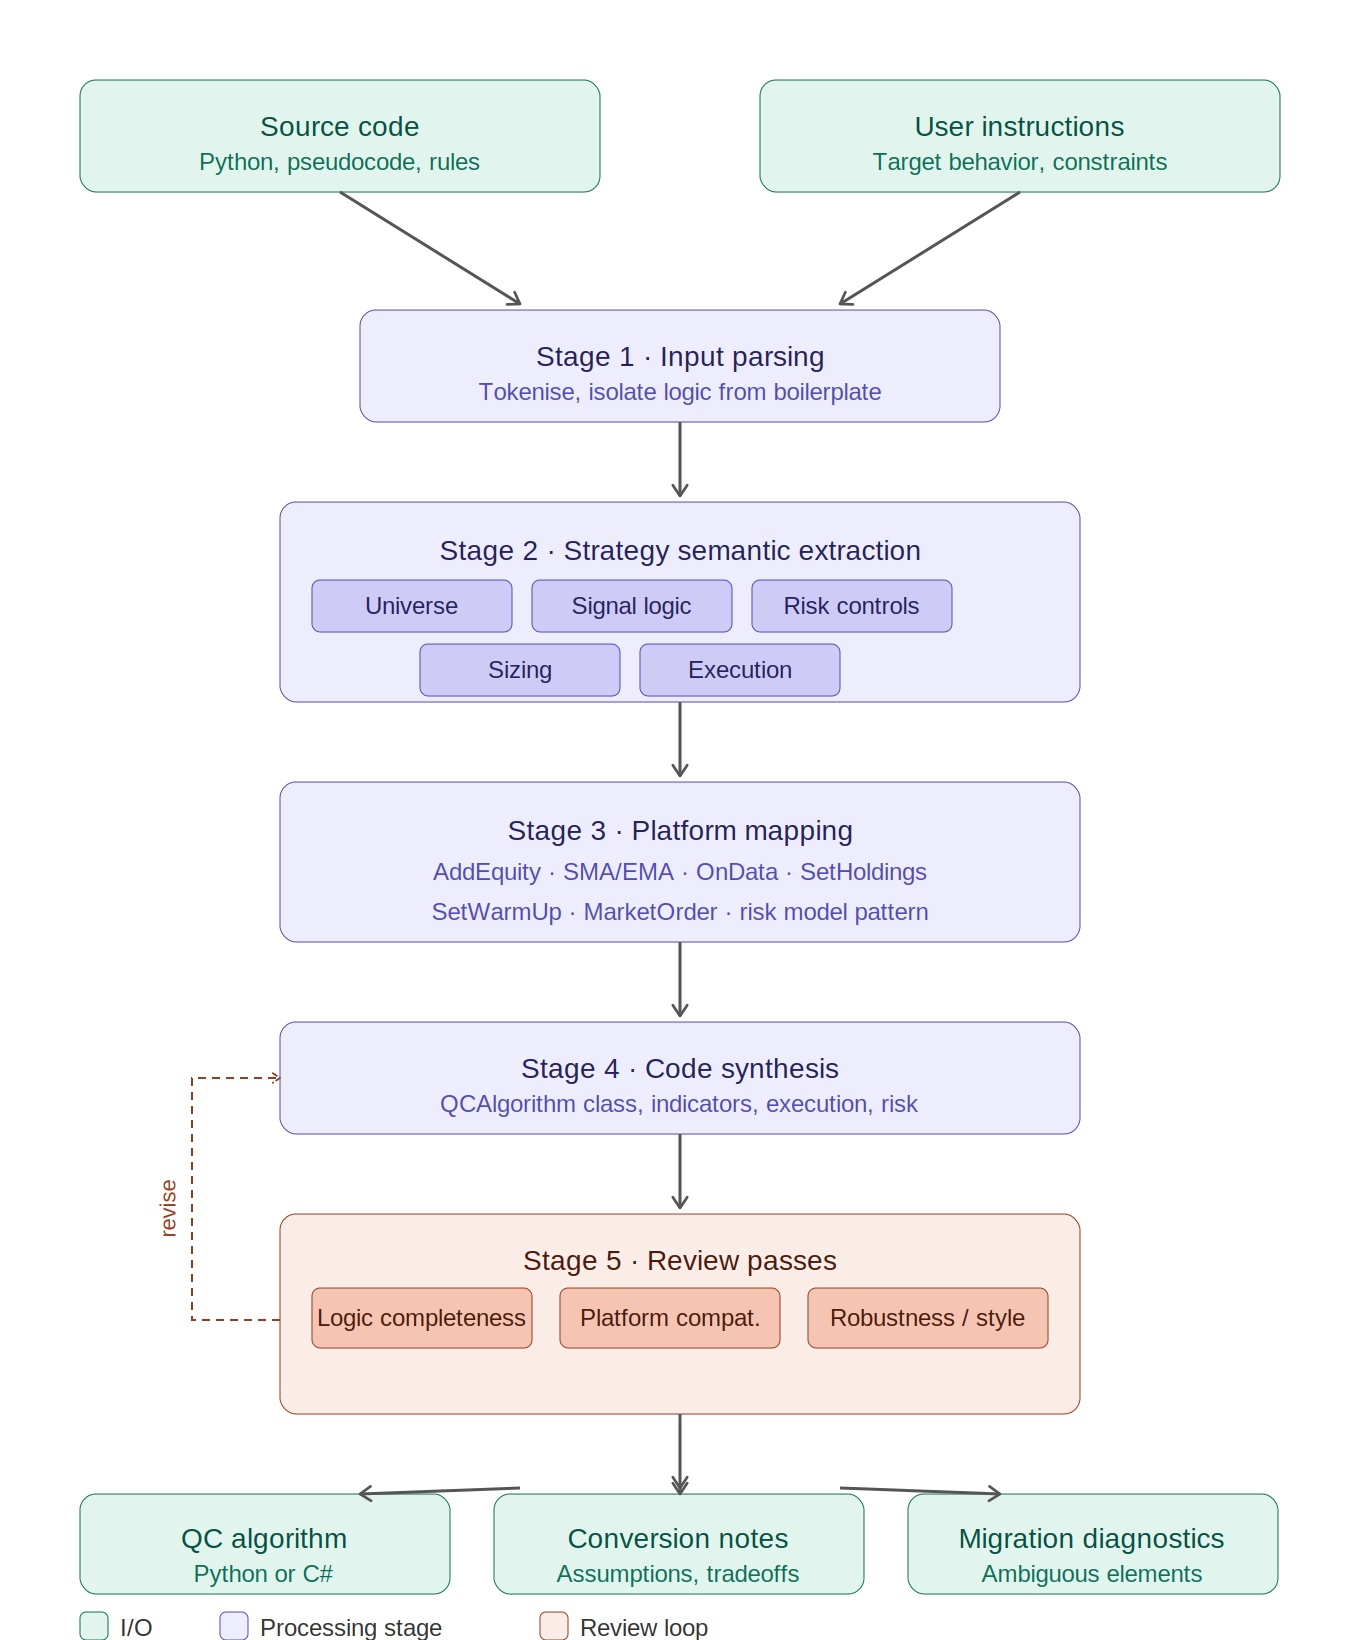

##2.CODE AND IMPLEMENTATION

###2.1.LIBRARIES AND ENVIRONMENT

In [ ]:
# ── CELL 1: Install dependencies ──────────────────────────
!pip install anthropic -q


# ── CELL 2: Imports & API key ─────────────────────────────
import anthropic
from google.colab import userdata

client = anthropic.Anthropic(api_key=userdata.get("ANTHROPIC_API_KEY"))
MODEL  = "claude-haiku-4-5-20251001"


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 469.4/469.4 kB 7.6 MB/s eta 0:00:00


###2.2.AGENT FUNCTIONS

In [ ]:

# ── CELL 3: Agent stage functions ─────────────────────────

def run_stage(stage_name: str, system_prompt: str, user_message: str,
              prior_output: str = "") -> str:
    """Send one stage request to Claude and return the text response."""
    print(f"\n{'='*60}")
    print(f"  STAGE: {stage_name}")
    print(f"{'='*60}")

    messages = []
    if prior_output:
        messages.append({
            "role": "assistant",
            "content": prior_output
        })
        messages.append({
            "role": "user",
            "content": user_message
        })
    else:
        messages.append({
            "role": "user",
            "content": user_message
        })

    response = client.messages.create(
        model=MODEL,
        max_tokens=2048,
        system=system_prompt,
        messages=messages
    )
    result = response.content[0].text
    print(result)
    return result


# ── Stage 1: Input Parsing ────────────────────────────────
def stage1_parse(source_code: str) -> str:
    system = """You are Stage 1 of a QuantConnect migration agent.
Your job is INPUT PARSING.
- Identify all syntactic units in the source code.
- Separate meaningful trading logic from boilerplate/imports.
- List what you find clearly under these headings:
  TRADING LOGIC ELEMENTS | BOILERPLATE / IMPORTS | AMBIGUOUS SECTIONS
Keep it concise and structured. No code generation yet."""

    user = f"""Parse the following source strategy code:\n\n```\n{source_code}\n```"""
    return run_stage("1 · Input Parsing", system, user)


# ── Stage 2: Semantic Extraction ─────────────────────────
def stage2_extract(parse_output: str) -> str:
    system = """You are Stage 2 of a QuantConnect migration agent.
Your job is STRATEGY SEMANTIC EXTRACTION.
Given a parsed breakdown, extract the strategy's operational intent under these headings:
  UNIVERSE        – instruments, asset class, data resolution
  SIGNAL LOGIC    – entry/exit rules, indicators, thresholds
  POSITION SIZING – fraction, volatility target, equal weight, etc.
  EXECUTION MODEL – order types, timing, rebalance schedule
  RISK CONTROLS   – stop-loss, drawdown limits, exposure caps
  STATE / WARMUP  – rolling windows, persistent variables, warm-up
Be precise. Flag anything ambiguous with [AMBIGUOUS]."""

    user = f"""Extract strategy semantics from this parsed analysis:\n\n{parse_output}"""
    return run_stage("2 · Semantic Extraction", system, user)


# ── Stage 3: Platform Mapping ─────────────────────────────
def stage3_map(semantic_output: str) -> str:
    system = """You are Stage 3 of a QuantConnect migration agent.
Your job is PLATFORM MAPPING.
Map every semantic component to its QuantConnect (Lean) equivalent.
Use this table format:

  SOURCE CONCEPT | QC EQUIVALENT | LOCATION (Initialize / OnData / runtime)

Cover: data subscriptions, indicators, scheduling, order methods,
risk patterns, warm-up, history calls.
Note where exact parity is impossible and propose the closest viable pattern."""

    user = f"""Map these semantic components to QuantConnect constructs:\n\n{semantic_output}"""
    return run_stage("3 · Platform Mapping", system, user)


# ── Stage 4: Code Synthesis ───────────────────────────────
def stage4_synthesize(mapping_output: str, source_code: str) -> str:
    system = """You are Stage 4 of a QuantConnect migration agent.
Your job is CODE SYNTHESIS.
Generate a complete, runnable QuantConnect Python algorithm (QCAlgorithm subclass).
Requirements:
  - from AlgorithmImports import *
  - Initialize() with SetStartDate, SetEndDate, SetCash, subscriptions, indicators, SetWarmUp
  - OnData() with warm-up guard, signal logic, order execution
  - Risk management checks
  - Comments marking any assumption or placeholder with # [ASSUMPTION] or # [PLACEHOLDER]
Output ONLY the Python code block. No prose before or after."""

    user = f"""Using this platform mapping:\n\n{mapping_output}

And the original source for reference:\n\n```\n{source_code}\n```

Generate the QuantConnect algorithm."""
    return run_stage("4 · Code Synthesis", system, user)


# ── Stage 5a: Review – Logic Completeness ─────────────────
def stage5a_review_logic(code: str, semantic_output: str) -> str:
    system = """You are Stage 5a of a QuantConnect migration agent.
Your job is LOGIC COMPLETENESS REVIEW.
Compare the generated code against the extracted semantics.
Check:
  - Every signal rule is implemented
  - Position sizing matches intent
  - Risk controls are present
  - Warm-up and state variables are correct
  - No silent omissions

Output a structured list:
  PRESENT     – items correctly implemented
  MISSING     – items omitted (must be fixed)
  UNCERTAIN   – items that need user clarification"""

    user = f"""Review this generated code for logic completeness.\n\nSEMANTICS:\n{semantic_output}\n\nCODE:\n{code}"""
    return run_stage("5a · Review: Logic Completeness", system, user)


# ── Stage 5b: Review – Platform Compatibility ─────────────
def stage5b_review_platform(code: str) -> str:
    system = """You are Stage 5b of a QuantConnect migration agent.
Your job is PLATFORM COMPATIBILITY REVIEW.
Check the code against QuantConnect/Lean conventions:
  - Correct API method signatures
  - No unsupported assumptions (e.g. same-bar fills)
  - Proper use of Resolution, Symbol, Portfolio APIs
  - No forbidden patterns (e.g. blocking calls in OnData)
  - Correct warm-up guard (self.IsWarmingUp)

Output:
  COMPATIBLE   – items that are correct
  FIX REQUIRED – specific line/pattern that must change, with the fix"""

    user = f"""Review this code for QuantConnect platform compatibility:\n\n{code}"""
    return run_stage("5b · Review: Platform Compatibility", system, user)


# ── Stage 5c: Review – Robustness & Style ─────────────────
def stage5c_review_style(code: str) -> str:
    system = """You are Stage 5c of a QuantConnect migration agent.
Your job is ROBUSTNESS AND STYLE REVIEW.
Improve the code for:
  - Readability and maintainability
  - Replacing fragile patterns with idiomatic QuantConnect constructs
  - Redundant order submissions guard
  - Clear variable names
  - Useful inline comments

Output the FINAL REVISED CODE as a clean Python code block.
This is the deliverable the user will copy into QuantConnect."""

    user = f"""Revise this code for robustness and style:\n\n{code}"""
    return run_stage("5c · Review: Robustness & Final Code", system, user)


# ── Stage 6: Migration Report ─────────────────────────────
def stage6_report(logic_review: str, platform_review: str,
                  source_code: str) -> str:
    system = """You are Stage 6 of a QuantConnect migration agent.
Your job is to write a concise MIGRATION REPORT.
Sections:
  SUMMARY          – one paragraph describing what was migrated
  ASSUMPTIONS      – list every [ASSUMPTION] made during conversion
  KNOWN LIMITATIONS – features that could not be fully reproduced
  RECOMMENDED TESTS – what the user should backtest/validate first
Keep it brief and actionable."""

    user = f"""Write the migration report.\n\nLOGIC REVIEW:\n{logic_review}\n\nPLATFORM REVIEW:\n{platform_review}\n\nORIGINAL SOURCE:\n{source_code}"""
    return run_stage("6 · Migration Report", system, user)



###2.3.SOURCE STRATEGY

In [ ]:
# ── CELL 4: Define your source strategy ───────────────────

SOURCE_STRATEGY = """
# Simple momentum strategy – generic Python backtest framework

import pandas as pd

SYMBOL     = "SPY"
FAST_PERIOD = 20
SLOW_PERIOD = 50
INITIAL_CASH = 100_000

def compute_signals(prices: pd.Series):
    fast = prices.rolling(FAST_PERIOD).mean()
    slow = prices.rolling(SLOW_PERIOD).mean()
    signal = (fast > slow).astype(int)
    return signal

def backtest(prices: pd.Series):
    signals = compute_signals(prices)
    position = 0
    portfolio = INITIAL_CASH

    for i in range(1, len(prices)):
        if signals.iloc[i] == 1 and position == 0:
            position = portfolio / prices.iloc[i]   # buy all-in
        elif signals.iloc[i] == 0 and position > 0:
            portfolio = position * prices.iloc[i]    # sell all
            position = 0

    if position > 0:
        portfolio = position * prices.iloc[-1]

    return portfolio
"""

###2.4.RUNNING THE PIPELINE

In [ ]:
# ── CELL 5: Run the full agent pipeline ───────────────────

print("\n" + "█"*60)
print("  QuantConnect Migration Agent  –  Starting pipeline")
print("█"*60)

# Stage 1
parsed        = stage1_parse(SOURCE_STRATEGY)

# Stage 2
semantics     = stage2_extract(parsed)

# Stage 3
mapping       = stage3_map(semantics)

# Stage 4
code_v1       = stage4_synthesize(mapping, SOURCE_STRATEGY)

# Stage 5 – three review passes
logic_review    = stage5a_review_logic(code_v1, semantics)
platform_review = stage5b_review_platform(code_v1)
final_code      = stage5c_review_style(code_v1)

# Stage 6
report          = stage6_report(logic_review, platform_review, SOURCE_STRATEGY)

print("\n" + "█"*60)
print("  PIPELINE COMPLETE")
print("█"*60)



████████████████████████████████████████████████████████████
  QuantConnect Migration Agent  –  Starting pipeline
████████████████████████████████████████████████████████████

  STAGE: 1 · Input Parsing
# INPUT PARSING ANALYSIS

## TRADING LOGIC ELEMENTS

1. **Strategy Type**: Momentum crossover (Moving Average)
2. **Parameters**:
   - `SYMBOL = "SPY"` – asset to trade
   - `FAST_PERIOD = 20` – short-term MA window
   - `SLOW_PERIOD = 50` – long-term MA window
   - `INITIAL_CASH = 100_000` – starting capital

3. **Signal Generation** (`compute_signals`):
   - Fast MA: 20-period rolling mean
   - Slow MA: 50-period rolling mean
   - Signal: 1 when fast > slow (bullish), 0 otherwise

4. **Position Management** (`backtest` loop):
   - **Entry**: Buy all-in when signal turns 1 (and not already holding)
   - **Exit**: Sell entire position when signal turns 0 (and holding)
   - **Final Settlement**: Close remaining position at final price

5. **Performance Metric**: Final portfolio value (i

###2.5.REPORT

In [ ]:
# ── CELL 6: Print just the final deliverables ─────────────

print("\n" + "="*60)
print("  FINAL QUANTCONNECT CODE")
print("="*60)
print(final_code)

print("\n" + "="*60)
print("  MIGRATION REPORT")
print("="*60)
print(report)


  FINAL QUANTCONNECT CODE
```python
from AlgorithmImports import *

class MASimpleCrossoverAlgorithm(QCAlgorithm):
    """
    MA Crossover Strategy: Long when 20-period SMA > 50-period SMA, exit otherwise.
    All-in/all-out position sizing with daily rebalancing.
    """
    
    # Configuration constants
    FAST_MA_PERIOD = 20
    SLOW_MA_PERIOD = 50
    EQUITY_SYMBOL = "SPY"
    RESOLUTION = Resolution.Daily
    
    def Initialize(self):
        """Initialize algorithm parameters, add securities, and set up indicators."""
        
        # Backtest date range and initial capital
        self.SetStartDate(2020, 1, 1)
        self.SetEndDate(2024, 1, 1)
        self.SetCash(100000)
        
        # Add SPY as the primary trading instrument
        self.symbol = self.AddEquity(self.EQUITY_SYMBOL, self.RESOLUTION).Symbol
        
        # Initialize fast (20-period) and slow (50-period) simple moving averages
        self.fast_ma = SimpleMovingAverage(self.FAST_MA_PERIOD)
      

##3.CONCLUSIONS

**Conclusion — Limitations and Areas for Improvement**

The pipeline described in this guide represents a solid foundation for automated strategy migration, but it is far from a finished product. Understanding where it falls short is as instructive as understanding how it works. Five areas stand out as the most promising directions for improvement.

---

**Richer context between stages**

The current design passes each stage's output to the next as plain text. This works, but it is fragile. If Stage 2 produces a slightly ambiguous semantic description, Stage 3 inherits that ambiguity and may resolve it incorrectly — and there is no mechanism for Stage 3 to ask Stage 2 a clarifying question. A more robust architecture would replace plain-text handoffs with structured data objects: typed dictionaries or Pydantic models that enforce a schema at each boundary. If Stage 2 must produce a field called execution_model with an enumerated value, it cannot accidentally omit it or mislabel it. Structured handoffs transform implicit contracts between stages into explicit, machine-verifiable ones, dramatically reducing the surface area for silent errors to propagate through the pipeline.

---

**No feedback loop from the user**

The pipeline currently runs from start to finish without pausing for human input. This is convenient for simple strategies but inadequate for complex ones. When Stage 2 flags a component as [AMBIGUOUS], the appropriate response is often to stop and ask the user what they meant — not to carry the ambiguity forward and hope that Stage 3 or Stage 4 resolves it correctly. A mature version of this agent would implement checkpoints: moments after Stage 1, Stage 2, and the review passes where the agent presents its current understanding to the user, asks targeted questions about flagged items, and incorporates the answers before proceeding. This human-in-the-loop design would not slow down simple migrations significantly, but it would dramatically improve accuracy on complex ones where ambiguity is the norm rather than the exception.

---

**No validation against a live QuantConnect environment**

The agent generates code and reviews it linguistically, but it never actually runs the code. A generated algorithm might pass all three review passes and still fail to compile in the Lean engine due to a subtle API version mismatch, a missing import, or an incorrect method signature introduced in a recent platform update. Integrating the QuantConnect CLI or the Lean Docker container into the pipeline would allow the agent to attempt a compilation pass after Stage 5c and feed any errors back as a fourth review pass. This would close the loop between code generation and code execution, catching an entire class of errors that linguistic review cannot detect.

---

**Single-strategy scope**

The current pipeline handles one strategy at a time, submitted as a single block of source code. Real-world migration projects rarely look like this. A production trading system might consist of a signal generator, a portfolio optimizer, a risk manager, and an execution layer — each in a separate file, each with its own dependencies. Extending the agent to handle multi-file, multi-component projects would require a preliminary stage that maps the dependency graph across files before parsing any individual component. This is a significantly harder problem, but it is the problem that most professional users actually face.

---

**Static prompts with no learning**

Every time the agent runs, it starts from scratch. If a user corrects a mistake — pointing out that the agent consistently misidentifies a particular pattern as a stop-loss when it is actually a take-profit — that correction disappears when the session ends. A more capable system would maintain a persistent memory of past corrections and edge cases, using them to refine the system prompts over time. In practice, this could be implemented as a small database of annotated examples that are retrieved and injected into the relevant stage prompts whenever a similar pattern is detected. This retrieval-augmented approach would allow the agent to improve continuously with use, turning each user correction into a permanent enhancement rather than a one-time fix.

---

These five limitations share a common theme: the current pipeline is open-loop, stateless, and linguistically bounded. The most impactful improvements would make it closed-loop through execution feedback, stateful through structured handoffs and persistent memory, and interactive through user checkpoints. None of these extensions are beyond reach. They represent the natural next layer of engineering on top of the foundation that this guide has described.